In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    "../data/raw/Processed_K50_dG_datasets/Tsuboyama2023_Dataset2_Dataset3_20230416.csv",
    low_memory=False
)


print(df.shape)
df.head()

(776298, 37)


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,...,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name
0,EA|run2_0325_0005.pdb,TCTGCTGGCGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.227105,1.255092,1.197643,0.057449,0.063626,-0.997071,2.998711,3.038485,...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2271050771597385,1.2135682995736825,3.3321258839433834,0.01719762915616707,False,NaN
1,EA|run2_0325_0005.pdb_wtm,TCCGCGGGTGGTTCCGCTGGCGGTTCTGCGGGCGGTGACGAAGTTA...,1.297559,1.381800,1.243835,0.137965,0.092264,-0.997071,3.099109,3.220506,...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2975591020191513,1.2201805304541726,3.3998316632160224,0.08490340842880606,False,NaN
2,EA|run2_0325_0005.pdb_wte,TCCGCTGGTGGCTCTGCGGGCGGTTCTGCTGGTGGCGACGAAGTTA...,1.262708,1.314787,1.239876,0.074911,0.092305,-0.997071,3.049332,3.123805,...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2627076164958364,1.169472475788951,3.315782210420261,0.0008539556330444675,False,NaN
3,EA|run2_0325_0005.pdb_wty,TCCGCTGGTGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.244782,1.314467,1.195005,0.119462,0.074537,-0.997071,3.023818,3.123346,...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2447822859698547,1.1543165166325822,3.272933265369934,-0.04199498941728219,False,NaN
4,EA|run2_0325_0005.pdb_wth,TCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCG...,0.998142,1.134508,0.723845,0.410663,0.315576,-1.010140,2.694897,2.885558,...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,0.9981417661631856,0.6573573370630326,2.570241917260095,-0.7446863375271211,False,NaN


It looks like there are many different mutations types including insertions. We want to subset the dataset down to just amino acid swaps. 

In [ ]:
df["mut_type"].value_counts(dropna=False)
#df["ddG_ML"].isna().value_counts()
#df["dG_ML"].isna().value_counts()


## We want to substitute down to only 
single_mut_df = df[df["mut_type"].str.fullmatch(r"[A-Z]\d+[A-Z]", na=False)].copy()
#print(df.shape) #(776298, 37))
#print(single_mut_df.shape) #(487914, 37)

single_mut_df[["name", "WT_name", "mut_type", "aa_seq", "ddG_ML"]].head(20)

## need to convert ddG_ML to strings 
single_mut_df['ddG_ML'] = pd.to_numeric(single_mut_df["ddG_ML"],errors="coerce")

single_mut_df['ddG_ML'].isna().sum() ## 98846
## Drop all ddG_ML that were NAs
single_mut_df = single_mut_df.dropna(subset=["ddG_ML"]).copy(). 
single_mut_df.shape #(389068, 37)

(776298, 37)
(487914, 37)


(389068, 37)

Single mutants: 389068
WT proteins: 412
WT clusters: 130


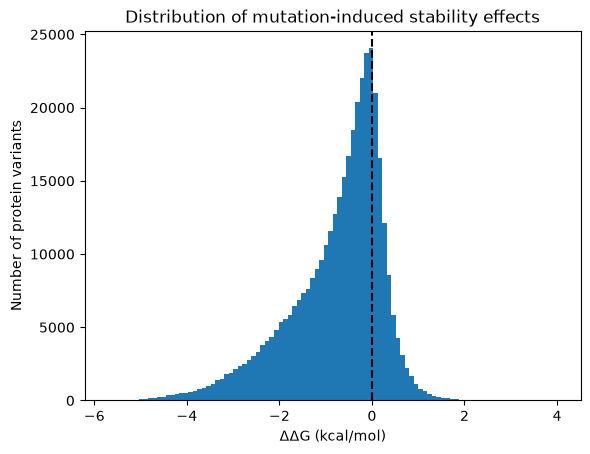

Fraction Stabilizing: 0.22184039807951308
Fraction Strongly Stabilizing: 0.008389278994931477


In [78]:
## Explore the data
print("Single mutants:", len(single_mut_df))
print("WT proteins:", single_mut_df["WT_name"].nunique())
print("WT clusters:", single_mut_df["WT_cluster"].nunique())

plt.hist(single_mut_df['ddG_ML'], bins = 100)
plt.axvline(0, linestyle="--", color = 'black')
plt.ylabel('Number of protein variants')
plt.xlabel("ΔΔG (kcal/mol)")
plt.title("Distribution of mutation-induced stability effects")
plt.show()

print('Fraction Stabilizing:', (single_mut_df['ddG_ML'] > 0).mean())
print('Fraction Strongly Stabilizing:', (single_mut_df['ddG_ML'] > 1).mean())

This makes sense as most mutations are destabilizing. Only a small fraction are stabilizing > 0 (22%)

In [ ]:
single_mut_df.head()

proteins_per_cluster = (
    single_mut_df[
        ["WT_name", "WT_cluster"]
    ]
    .drop_duplicates()
    .groupby("WT_cluster")
    .size()
)

proteins_per_cluster.describe()
single_mut_df[["WT_name", "WT_cluster"]]
single_mut_df[["WT_cluster"]].value_counts()


(389068, 37)

We still need to extract some additional data about where amino acid is lcoated

In [120]:
from numpy import int64
def parse_mutation(df):
    df = df.copy()

    df['wt_aa'] = df['mut_type'].str.extract(r"^([A-Z])")

    df['mut_aa'] = df['mut_type'].str.extract(r".*[0-9]([A-Z])$")

    df['position'] = df['mut_type'].str.extract(r"^[A-Z]([0-9]+)[A-Z]$", expand = False).astype("Int64")

    df['protein_length'] = df['aa_seq'].str.len()
    
    df["relative_position"] = (
        df["position"] / df["protein_length"]
    )

    return df

single_mut_df[["mut_type", "aa_seq", "ddG_ML"]]

test = single_mut_df[["mut_type", "aa_seq", "ddG_ML"]].copy()

test = parse_mutation(test)

test.head()

,mut_type,aa_seq,ddG_ML,wt_aa,mut_aa,position,protein_length,relative_position
5,D1Q,QEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,-0.072296,D,Q,1,47,0.021277
6,D1E,EEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,-0.067661,D,E,1,47,0.021277
7,D1N,NEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,-0.045815,D,N,1,47,0.021277
8,D1H,HEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,-0.080105,D,H,1,47,0.021277
9,D1R,REVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,-0.402889,D,R,1,47,0.021277


In [127]:
## Ok lets get single_mut_df ready for processing
single_mut_df[["mut_type", "aa_seq", "ddG_ML"]]
X_df = single_mut_df[["WT_name", "mut_type", "aa_seq"]].copy()
X_df = parse_mutation(X_df)

y_df = single_mut_df["ddG_ML"].copy()

print(X_df.shape)
print(y_df.shape)
X_df

X_df.to_pickle('../data/processed/X_df.pkl')
y_df.to_pickle('../data/processed/y_df.pkl')

(389068, 8)
(389068,)


Moving onto notebook 2 we will split the data and begin building the model.